In [2]:
# Step 1: Data Cleaning & Preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

# Load dataset
file_path = r"C:\Users\ASUS\Downloads\otolith_summary.csv"
df = pd.read_csv(file_path)

# Preview data
print(df.head())
print(df.info())

# Handle missing values: replace 'nd' with NaN
df.replace('nd', np.nan, inplace=True)

# Convert numeric columns to float
numeric_cols = ['std_length', 'pel_larv_dur', 'juv_age',
                'larval_radius', 'settle_radius', 'otolith_radius',
                'larval_growth_avg', 'juv_growth_avg', 'juv_growth_1_2_d_avg',
                'temp_larval', 'temp_juv', 'density_juv', 'density_int', 'density_adult']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert date columns to datetime
date_cols = ['date_collected', 'date_hatched', 'date_spawn', 'date_settled']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce')

# Fill missing numeric values with mean (assign back to avoid FutureWarning)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Encode categorical columns
categorical_cols = ['stage', 'collection', 'site_name', 'site_code', 
                    'monthly_cohort', 'site_descrip', 'collect_catch_or_density',
                    'lunar_phase_spawn', 'lunar_phase_settled', 'tidal_day_settled']

le_dict = {}
for col in categorical_cols:
    df[col] = df[col].astype(str)  # Ensure string type
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Feature Engineering: create age difference columns
df['larval_duration_days'] = (df['date_settled'] - df['date_spawn']).dt.days
df['juvenile_age_days'] = (df['date_collected'] - df['date_hatched']).dt.days

# Final cleaned dataset
df_cleaned = df.copy()
print(df_cleaned.head())

# Save cleaned dataset for further use
df_cleaned.to_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv", index=False)


      stage date_collected  collection     site_name site_code  site_lat  \
0  Juvenile       20030412           1  Pickles_Reef        PI  24.98717   
1  Juvenile       20030412           2  Pickles_Reef        PI  24.98717   
2  Juvenile       20030412           2  Pickles_Reef        PI  24.98717   
3  Juvenile       20030412           2  Pickles_Reef        PI  24.98717   
4  Juvenile       20030412           2  Pickles_Reef        PI  24.98717   

   site_lon  sample std_length monthly_cohort  ... settle_radius  \
0 -80.41467       1   12.26229         Mar-03  ...    225.600006   
1 -80.41467       1   15.27673         Mar-03  ...    246.350006   
2 -80.41467       2   13.63182         Mar-03  ...    236.979996   
3 -80.41467       3   17.12785         Mar-03  ...    268.290008   
4 -80.41467       5   21.03063         Mar-03  ...    247.210007   

   otolith_radius  larval_growth_avg juv_growth_avg juv_growth_1_2_d_avg  \
0      253.929993        7.253103618    5.131248474       

Growth Prediction Model - MSE: 0.163, R2 Score: 0.486


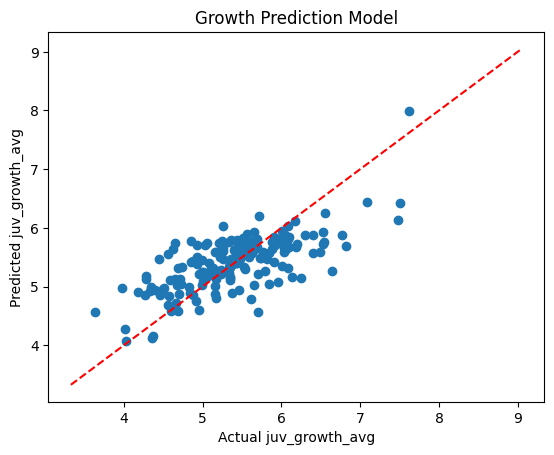

Predicted juvenile growth for sample input: 5.340649254979996


In [4]:
# Step 2: Growth Prediction Model with manual sample input
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load cleaned data
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# Define features and target
features = ['pel_larv_dur', 'juv_age', 'temp_larval', 'temp_juv', 
            'larval_radius', 'settle_radius', 'larval_growth_avg', 
            'larval_duration_days', 'juvenile_age_days', 'lunar_phase_spawn', 'site_code']
target = 'juv_growth_avg'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)

# Performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Growth Prediction Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual juv_growth_avg")
plt.ylabel("Predicted juv_growth_avg")
plt.title("Growth Prediction Model")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# -------------------------------
# Manual sample input for prediction
# -------------------------------
# Create a sample with values for each feature
# Example values (you can change these manually)
sample_input = pd.DataFrame({
    'pel_larv_dur': [30],
    'juv_age': [15],
    'temp_larval': [25.5],
    'temp_juv': [24.8],
    'larval_radius': [200],
    'settle_radius': [250],
    'larval_growth_avg': [7.0],
    'larval_duration_days': [33],
    'juvenile_age_days': [35],
    'lunar_phase_spawn': [0],  # encoded value
    'site_code': [2]            # encoded value
})

# Predict using the trained model
pred_sample = model.predict(sample_input)
print("Predicted juvenile growth for sample input:", pred_sample[0])


Settlement Prediction Model - MSE: 0.701, R2 Score: 0.998


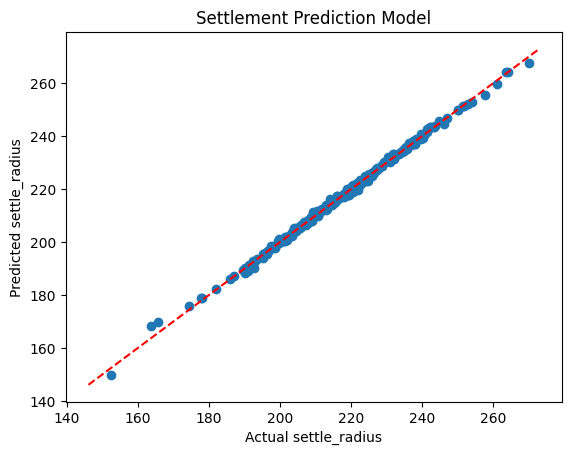

Manual sample predicted settlement radius: 149.29795184699972


In [6]:
# Step 3: Settlement Prediction Model with manual sample input
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load cleaned data
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# Features and target
features = ['pel_larv_dur', 'temp_larval', 'temp_juv', 
            'larval_radius', 'larval_growth_avg', 'juvenile_age_days', 
            'lunar_phase_spawn', 'site_code']
target = 'settle_radius'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)

# Performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Settlement Prediction Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual settle_radius")
plt.ylabel("Predicted settle_radius")
plt.title("Settlement Prediction Model")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# --- Manual sample input (random values) ---
# Make sure the sample has the same feature order
sample_input = pd.DataFrame({
    'pel_larv_dur': [15],       # example larval duration in days
    'temp_larval': [27.5],      # example larval temp
    'temp_juv': [26.0],         # example juvenile temp
    'larval_radius': [0.12],    # example larval otolith radius
    'larval_growth_avg': [0.02],# example larval growth
    'juvenile_age_days': [30],  # example juvenile age
    'lunar_phase_spawn': [2],   # encoded lunar phase (number)
    'site_code': [5]            # encoded site code (number)
})

# Predict for manual sample
pred_sample = model.predict(sample_input)
print("Manual sample predicted settlement radius:", pred_sample[0])


Population Density Model - MSE: 0.001, R2 Score: 0.815


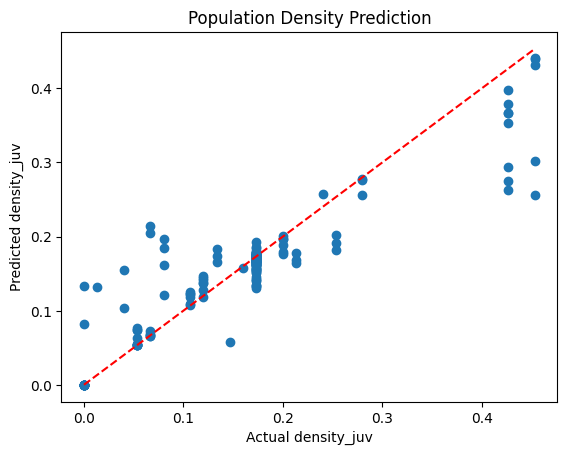

Manual sample predicted density: 0.1455071831370704


In [7]:
# Step 4: Population Density Prediction Model with manual sample input
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load cleaned data
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# Features and target
features = ['juv_growth_avg', 'larval_growth_avg', 'temp_larval', 'temp_juv', 
            'larval_radius', 'settle_radius', 'larval_duration_days', 'juvenile_age_days', 
            'lunar_phase_spawn', 'site_code']
target = 'density_juv'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)

# Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Population Density Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual density_juv")
plt.ylabel("Predicted density_juv")
plt.title("Population Density Prediction")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# --- Manual sample input ---
# Random values for each feature (replace with your own if needed)
sample_input = pd.DataFrame({
    'juv_growth_avg': [5.2],
    'larval_growth_avg': [3.8],
    'temp_larval': [27.5],
    'temp_juv': [28.0],
    'larval_radius': [1.5],
    'settle_radius': [2.3],
    'larval_duration_days': [15],
    'juvenile_age_days': [30],
    'lunar_phase_spawn': [0.6],  # normalized lunar phase or 0-1
    'site_code': [101]  # example site code
})

# Prediction for manual sample
pred_sample = model.predict(sample_input)
print("Manual sample predicted density:", pred_sample[0])


# model save

Growth Prediction Model - MSE: 0.163, R2 Score: 0.486


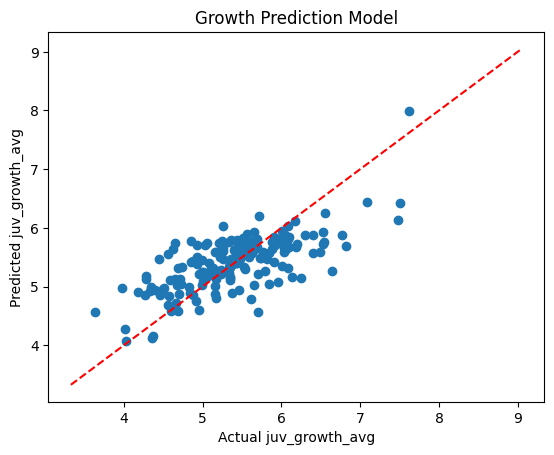

Predicted juvenile growth for sample input: 5.340649254979996
Trained model saved as 'C:\Users\ASUS\Downloads\growth_model.pkl'


In [1]:
# Step 2: Growth Prediction Model with manual sample input + saving with pickle

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle  # <-- for saving the model

# -------------------------------
# 1. Load cleaned data
# -------------------------------
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# -------------------------------
# 2. Define features and target
# -------------------------------
features = ['pel_larv_dur', 'juv_age', 'temp_larval', 'temp_juv', 
            'larval_radius', 'settle_radius', 'larval_growth_avg', 
            'larval_duration_days', 'juvenile_age_days', 'lunar_phase_spawn', 'site_code']
target = 'juv_growth_avg'

X = df[features]
y = df[target]

# -------------------------------
# 3. Split data into training and testing
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 4. Train Random Forest Regressor
# -------------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 5. Evaluate model performance
# -------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Growth Prediction Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual juv_growth_avg")
plt.ylabel("Predicted juv_growth_avg")
plt.title("Growth Prediction Model")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# -------------------------------
# 6. Predict with manual sample input
# -------------------------------
sample_input = pd.DataFrame({
    'pel_larv_dur': [30],
    'juv_age': [15],
    'temp_larval': [25.5],
    'temp_juv': [24.8],
    'larval_radius': [200],
    'settle_radius': [250],
    'larval_growth_avg': [7.0],
    'larval_duration_days': [33],
    'juvenile_age_days': [35],
    'lunar_phase_spawn': [0],  # encoded value
    'site_code': [2]            # encoded value
})

pred_sample = model.predict(sample_input)
print("Predicted juvenile growth for sample input:", pred_sample[0])

# -------------------------------
# 7. Save trained model using pickle
# -------------------------------
model_file = r"C:\Users\ASUS\Downloads\growth_model.pkl"
with open(model_file, 'wb') as file:
    pickle.dump(model, file)

print(f"Trained model saved as '{model_file}'")


Settlement Prediction Model - MSE: 0.701, R2 Score: 0.998


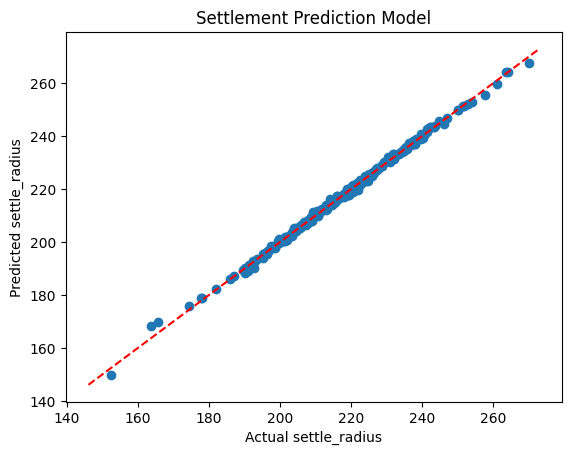

Manual sample predicted settlement radius: 149.29795184699972
Trained model saved as 'C:\Users\ASUS\Downloads\settlement_model.pkl'


In [2]:
# Step 3: Settlement Prediction Model with manual sample input + saving with pickle

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle  # <-- for saving the model

# -------------------------------
# 1. Load cleaned data
# -------------------------------
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# -------------------------------
# 2. Define features and target
# -------------------------------
features = ['pel_larv_dur', 'temp_larval', 'temp_juv', 
            'larval_radius', 'larval_growth_avg', 'juvenile_age_days', 
            'lunar_phase_spawn', 'site_code']
target = 'settle_radius'

X = df[features]
y = df[target]

# -------------------------------
# 3. Split data into training and testing
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 4. Train Random Forest Regressor
# -------------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 5. Evaluate model performance
# -------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Settlement Prediction Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual settle_radius")
plt.ylabel("Predicted settle_radius")
plt.title("Settlement Prediction Model")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# -------------------------------
# 6. Predict with manual sample input
# -------------------------------
sample_input = pd.DataFrame({
    'pel_larv_dur': [15],        # example larval duration in days
    'temp_larval': [27.5],       # example larval temperature
    'temp_juv': [26.0],          # example juvenile temperature
    'larval_radius': [0.12],     # example larval otolith radius
    'larval_growth_avg': [0.02], # example larval growth average
    'juvenile_age_days': [30],   # example juvenile age
    'lunar_phase_spawn': [2],    # encoded lunar phase
    'site_code': [5]             # encoded site code
})

pred_sample = model.predict(sample_input)
print("Manual sample predicted settlement radius:", pred_sample[0])

# -------------------------------
# 7. Save trained model using pickle
# -------------------------------
model_file = r"C:\Users\ASUS\Downloads\settlement_model.pkl"
with open(model_file, 'wb') as file:
    pickle.dump(model, file)

print(f"Trained model saved as '{model_file}'")


Population Density Model - MSE: 0.001, R2 Score: 0.815


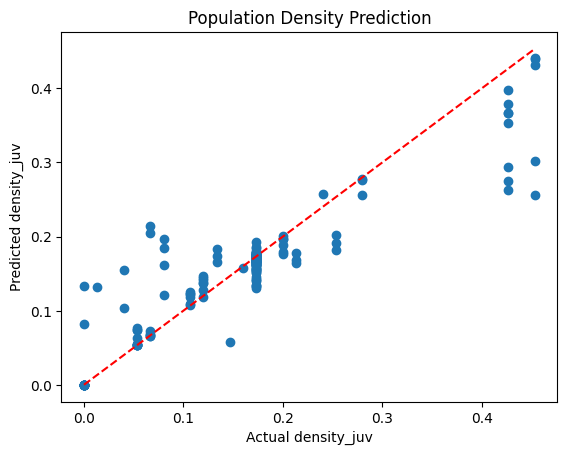

Manual sample predicted density: 0.1455071831370704
Trained model saved as 'C:\Users\ASUS\Downloads\density_model.pkl'


In [3]:
# Step 4: Population Density Prediction Model with manual sample input + saving with pickle

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle  # <-- for saving the model

# -------------------------------
# 1. Load cleaned data
# -------------------------------
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# -------------------------------
# 2. Define features and target
# -------------------------------
features = ['juv_growth_avg', 'larval_growth_avg', 'temp_larval', 'temp_juv', 
            'larval_radius', 'settle_radius', 'larval_duration_days', 'juvenile_age_days', 
            'lunar_phase_spawn', 'site_code']
target = 'density_juv'

X = df[features]
y = df[target]

# -------------------------------
# 3. Split data into training and testing
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 4. Train Random Forest Regressor
# -------------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 5. Evaluate model performance
# -------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Population Density Model - MSE: {mse:.3f}, R2 Score: {r2:.3f}")

# Plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual density_juv")
plt.ylabel("Predicted density_juv")
plt.title("Population Density Prediction")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# -------------------------------
# 6. Predict with manual sample input
# -------------------------------
sample_input = pd.DataFrame({
    'juv_growth_avg': [5.2],
    'larval_growth_avg': [3.8],
    'temp_larval': [27.5],
    'temp_juv': [28.0],
    'larval_radius': [1.5],
    'settle_radius': [2.3],
    'larval_duration_days': [15],
    'juvenile_age_days': [30],
    'lunar_phase_spawn': [0.6],  # normalized lunar phase or 0-1
    'site_code': [101]            # example site code
})

pred_sample = model.predict(sample_input)
print("Manual sample predicted density:", pred_sample[0])

# -------------------------------
# 7. Save trained model using pickle
# -------------------------------
model_file = r"C:\Users\ASUS\Downloads\density_model.pkl"
with open(model_file, 'wb') as file:
    pickle.dump(model, file)

print(f"Trained model saved as '{model_file}'")


Survival Prediction Accuracy: 1.000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       179
           1       1.00      1.00      1.00        78

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257



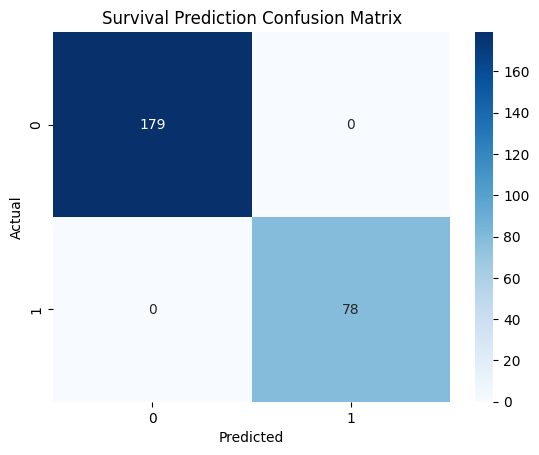

Sample predicted survival: Died
Trained model saved as 'C:\Users\ASUS\Downloads\survival_model.pkl'


In [4]:
# Step 5: Survival / Mortality Prediction Model with manual sample input + saving with pickle

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle  # <-- for saving the model

# -------------------------------
# 1. Load cleaned data
# -------------------------------
df = pd.read_csv(r"C:\Users\ASUS\Downloads\otolith_cleaned.csv")

# -------------------------------
# 2. Create survival column
# -------------------------------
median_age = df['juv_age'].median()
df['survived'] = (df['juv_age'] > median_age).astype(int)

# Ensure 'larval_age_days' exists
if 'larval_age_days' not in df.columns:
    if 'juvenile_age_days' in df.columns:
        df['larval_age_days'] = df['juvenile_age_days'] - df['larval_duration_days']
    else:
        df['larval_age_days'] = df['larval_duration_days'] * 0.5

# -------------------------------
# 3. Define features and target
# -------------------------------
features = ['juv_growth_avg', 'larval_growth_avg', 'temp_larval', 'temp_juv',
            'larval_radius', 'settle_radius', 'larval_duration_days', 
            'larval_age_days', 'lunar_phase_spawn', 'site_code']
target = 'survived'

# Fill missing values with median
df[features] = df[features].fillna(df[features].median())

X = df[features]
y = df[target]

# -------------------------------
# 4. Split data into training and testing
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 5. Train Random Forest Classifier
# -------------------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 6. Evaluate model performance
# -------------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Survival Prediction Accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Survival Prediction Confusion Matrix")
plt.show()

# -------------------------------
# 7. Predict with manual sample input
# -------------------------------
sample_input = pd.DataFrame({
    'juv_growth_avg': [0.8],
    'larval_growth_avg': [0.5],
    'temp_larval': [27.0],
    'temp_juv': [28.5],
    'larval_radius': [0.3],
    'settle_radius': [0.5],
    'larval_duration_days': [15],
    'larval_age_days': [5],
    'lunar_phase_spawn': [2],
    'site_code': [101]
})

pred_sample = model.predict(sample_input)
print("Sample predicted survival:", "Survived" if pred_sample[0]==1 else "Died")

# -------------------------------
# 8. Save trained model using pickle
# -------------------------------
model_file = r"C:\Users\ASUS\Downloads\survival_model.pkl"
with open(model_file, 'wb') as file:
    pickle.dump(model, file)

print(f"Trained model saved as '{model_file}'")
